In [109]:
!pip install ripser persim

In [110]:
!pip install gudhi

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.spatial import cKDTree
import pandas as pd


from pyproj import Transformer
from ripser import ripser
from persim import plot_diagrams
import gudhi as gd
from pyproj import Transformer

**Limpieza de datos y preprocesamiento**

In [112]:
# importar datos
df_cdmx = pd.read_csv('denue_inegi_09_.csv', encoding='latin1')
df_edo1 = pd.read_csv('denue_inegi_15_1.csv', encoding='latin1')
df_edo2 = pd.read_csv('denue_inegi_15_2.csv', encoding='latin1')

/tmp/ipykernel_56269/3156307173.py:2: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df_cdmx = pd.read_csv('denue_inegi_09_.csv', encoding='latin1')


In [113]:
# Ver cuántos datos hay para sector salud
df_cdmx['codigo_act1_digits'] = df_cdmx['codigo_act'].astype(str).str[:2]
df_edo1['codigo_act2_digits'] = df_edo1['codigo_act'].astype(str).str[:2]
df_edo2['codigo_act3_digits'] = df_edo2['codigo_act'].astype(str).str[:2]

df_cdmx['codigo_act1_digits'].value_counts()

,count
codigo_act1_digits,
46,210168
81,67363
72,57721
62,22841
31,17908
43,13458
54,11058
61,10448
52,10226


In [114]:
df_edo1['codigo_act2_digits'].value_counts()

,count
codigo_act2_digits,
46,396591
31,45783
43,18966
33,16391
32,13159
53,7780
52,7566
54,5984
48,2164


In [115]:
df_edo2['codigo_act3_digits'].value_counts()

,count
codigo_act3_digits,
81,122568
72,94042
62,31260
61,19753
71,8977
56,8498
93,6209
54,5389
55,19


La primer base de datos, del Estado de México no contiene el sector 62, por lo que unicámente se utilizara df_edo2.

In [116]:
df_cdmx.shape

(460761, 43)

In [117]:
# filtrar los primeros dos dígitos para 62
df_cdmx = df_cdmx[df_cdmx['codigo_act1_digits'].str[:2] == '62']
df_edo2 = df_edo2[df_edo2['codigo_act3_digits'].str[:2] == '62']

print(df_cdmx.shape)
print(df_edo2.shape)

(22841, 43)
(31260, 43)


In [118]:
# Join df_cdmx and df_edo2
df_metropolitana = pd.concat([df_cdmx, df_edo2])

df_metropolitana.head()

df_metropolitana.shape

(54101, 44)

In [119]:
df_metropolitana = df_metropolitana.drop(columns=['codigo_act1_digits', 'codigo_act3_digits'])
df_metropolitana.head()

,id,clee,nom_estab,raz_social,codigo_act,nombre_act,per_ocu,tipo_vial,nom_vial,tipo_v_e_1,...,localidad,ageb,manzana,telefono,correoelec,www,tipoUniEco,latitud,longitud,fecha_alta
304457,11822253,09015621411000053000061236S6,MARIE STOPES CONDESA,FUNDACION MARIE STOPES MEXICO AC,621411,Centros de planificación familiar del sector p...,11 a 30 personas,CALLE,Atlixco,AVENIDA,...,Cuauhtémoc ...,1182,2,5.560513e+09,MAYRA.CRUZ@MARIESTOPES.ORG.MX,WWW.MARIESTOPES.ORG.MX,Fijo,19.415518,-99.172861,2025-04
304458,6795800,09013621511000421000003549S7,113 LABORATORIO MEDICO DEL CHOPO SUCURSAL ARENAL,GRUPO DIAGNOSTICO MEDICO PROA SA DE CV,621511,Laboratorios médicos y de diagnóstico del sect...,0 a 5 personas,CALLE,PASEO DE LA VIRGEN,CALLE,...,Xochimilco ...,0014,15,NaN,INFORMES.WEB@CHOPO.COM.MX,WWW.CHOPO.COM.MX,Fijo,19.280340,-99.137950,2017-03
304459,8485187,09015624191001661000000000S0,19 DISTRITO DE SERVICIOS GENERALES ALCOHOLICOS...,DAMIAN INIESTRA ANTUNEZ AC,624191,Agrupaciones de autoayuda para alcohólicos y p...,0 a 5 personas,CALLE,LUDWING VAN BEETHOVEN,CALLE,...,Cuauhtémoc ...,0023,11,5.587393e+09,NaN,NaN,Fijo,19.460542,-99.131678,2019-11
304460,767683,09005624191000011001000000U0,1ER DISTRITO AREA NORTE DE ALCOHOLICOS ANONIMOS,ALCOHOLICOS ANONIMOS AC,624191,Agrupaciones de autoayuda para alcohólicos y p...,0 a 5 personas,CALLE,306,CALLE,...,Gustavo A. Madero ...,1186,15,NaN,NaN,NaN,Fijo,19.492214,-99.087259,2010-07
304461,11366041,09017621211005831000000000U0,20 DENTAL,NaN,621211,Consultorios dentales del sector privado,0 a 5 personas,CALLE,CERAMICA,CALLE,...,Venustiano Carranza ...,0282,25,NaN,NaN,NaN,Fijo,19.440626,-99.107722,2024-11


In [120]:
# Explorar datos
df_metropolitana.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54101 entries, 304457 to 64918
Data columns (total 42 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          54101 non-null  int64  
 1   clee        54101 non-null  object 
 2   nom_estab   54101 non-null  object 
 3   raz_social  11909 non-null  object 
 4   codigo_act  54101 non-null  int64  
 5   nombre_act  54101 non-null  object 
 6   per_ocu     54101 non-null  object 
 7   tipo_vial   54101 non-null  object 
 8   nom_vial    54100 non-null  object 
 9   tipo_v_e_1  54101 non-null  object 
 10  nom_v_e_1   54099 non-null  object 
 11  tipo_v_e_2  54101 non-null  object 
 12  nom_v_e_2   54099 non-null  object 
 13  tipo_v_e_3  54101 non-null  object 
 14  nom_v_e_3   54084 non-null  object 
 15  numero_ext  50667 non-null  float64
 16  letra_ext   25476 non-null  object 
 17  edificio    8778 non-null   object 
 18  edificio_e  8725 non-null   object 
 19  numero_int  24675 non-nul

In [121]:
print(df_metropolitana['entidad'].value_counts())
print(df_metropolitana['municipio'].value_counts().head(20))

entidad
México              31260
Ciudad de México    22841
Name: count, dtype: int64
municipio
Iztapalapa              3377
Ecatepec de Morelos     3373
Gustavo A. Madero       2682
Cuauhtémoc              2660
Nezahualcóyotl          2417
Toluca                  2281
Benito Juárez           2075
Tlalpan                 1702
Tlalnepantla de Baz     1686
Miguel Hidalgo          1622
Naucalpan de Juárez     1582
Coyoacán                1503
Álvaro Obregón          1487
Cuautitlán Izcalli      1156
Metepec                  989
Venustiano Carranza      963
Atizapán de Zaragoza     950
Azcapotzalco             890
Iztacalco                827
Tecámac                  817
Name: count, dtype: int64


In [122]:
df_metropolitana['entidad'].value_counts()

,count
entidad,
México,31260
Ciudad de México,22841


Para este proyecto en particular se necesitarán las coordenadas geográficas, el código del sector y la entidad. Por lo mismo, a continuación se hara un filtro para tener unicámente las columnas indicadas.

In [123]:
df_analisis = df_metropolitana[['entidad', 'codigo_act', 'latitud', 'longitud']]

df_analisis.head()

,entidad,codigo_act,latitud,longitud
304457,Ciudad de México,621411,19.415518,-99.172861
304458,Ciudad de México,621511,19.280340,-99.137950
304459,Ciudad de México,624191,19.460542,-99.131678
304460,Ciudad de México,624191,19.492214,-99.087259
304461,Ciudad de México,621211,19.440626,-99.107722


In [124]:
df_analisis.shape

(54101, 4)

In [125]:
df_analisis.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54101 entries, 304457 to 64918
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   entidad     54101 non-null  object 
 1   codigo_act  54101 non-null  int64  
 2   latitud     54101 non-null  float64
 3   longitud    54101 non-null  float64
dtypes: float64(2), int64(1), object(1)
memory usage: 2.1+ MB


In [126]:
df_analisis.isna().sum()

,0
entidad,0
codigo_act,0
latitud,0
longitud,0


Una vez filtrando los datos, no hay ningún valor nulo. Teniendo esta base de datos, es posible realizar una exploración de los datos y realizar visualizaciones iniciales.

**Visualización descriptiva inicial**


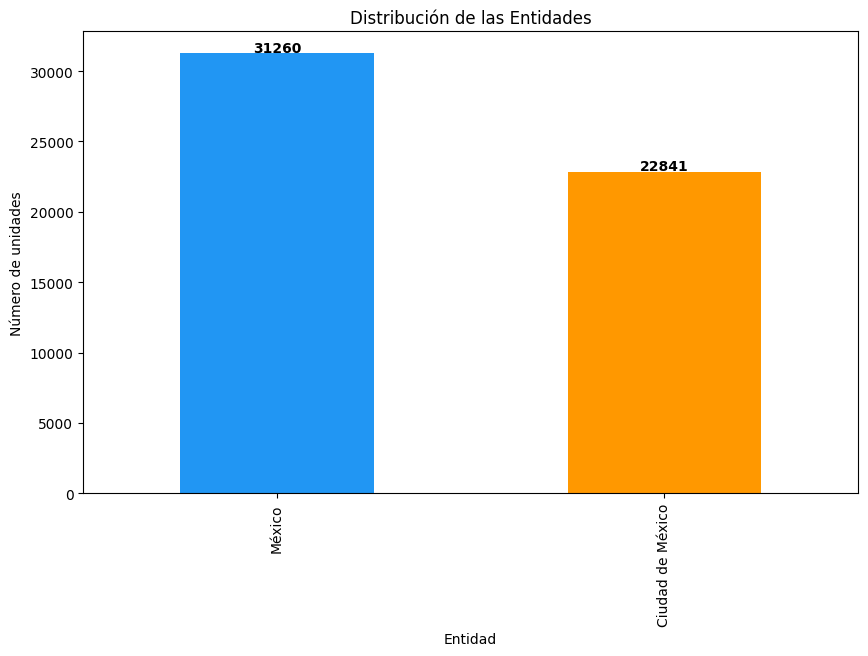

In [127]:
# Bar plot distribución CDMX y EDOMEX
plt.figure(figsize=(10, 6))
df_metropolitana['entidad'].value_counts().plot(kind='bar', color=['#2196F3', '#FF9800'])
plt.title('Distribución de las Entidades')
plt.xlabel('Entidad')
plt.ylabel('Número de unidades')
# escribir total en bar plot
for i, v in enumerate(df_metropolitana['entidad'].value_counts()):
    plt.text(i, v + 100, str(v), ha='center', fontweight='bold')
plt.show()

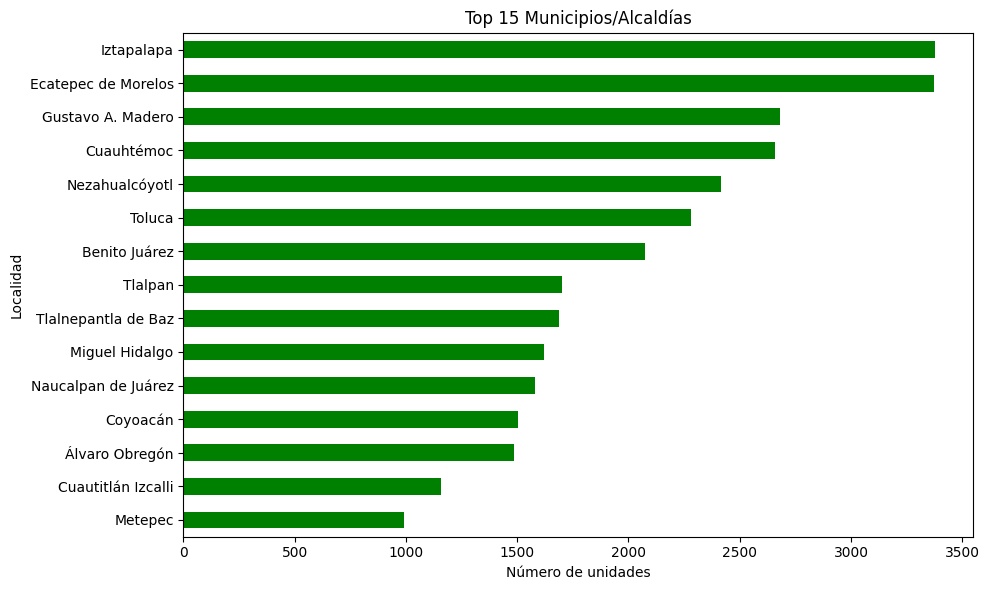

Text(0.5, 1.0, '15 Municipios/Alcaldías con menos establecimientos')

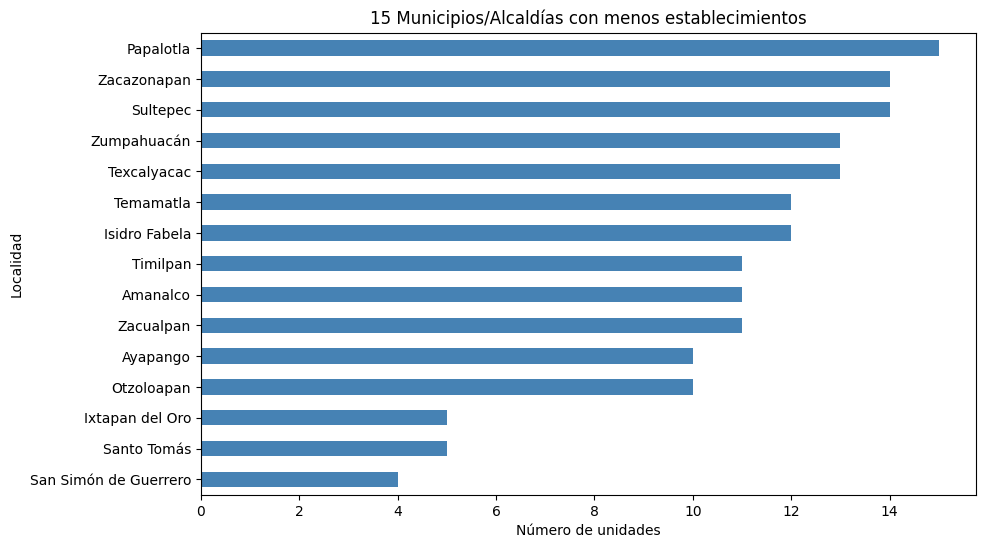

In [128]:
# Ver el top 15 municipios con más establecimientos.
df_metropolitana['municipio'].value_counts().head(15).sort_values().plot(
    kind='barh', figsize=(10, 6), color='green', edgecolor='none')
plt.title('Top 15 Municipios/Alcaldías')
plt.xlabel('Número de unidades')
plt.ylabel('Localidad')
plt.tight_layout()
plt.show()

# Ver los 15 municipios y alcaldías con menos consultoríos en sector salud.
df_metropolitana['municipio'].value_counts().tail(15).sort_values().plot(
    kind='barh', figsize=(10, 6), color='steelblue', edgecolor='none')
plt.ylabel('Localidad')
plt.xlabel('Número de unidades')
plt.title('15 Municipios/Alcaldías con menos establecimientos')

En particular se puede observar como es que en el top 15 de alcaldías o municipios, se encuentran en su mayoría todas las alcaldías de la Ciudad de México. Mientras que en la gráfica de municipios con menos establecimientos, todos son municipios del Estado de México. Esto puede ser un indicador de que en la capital hay más consultorios o establecimientos dedicados al sector salud.

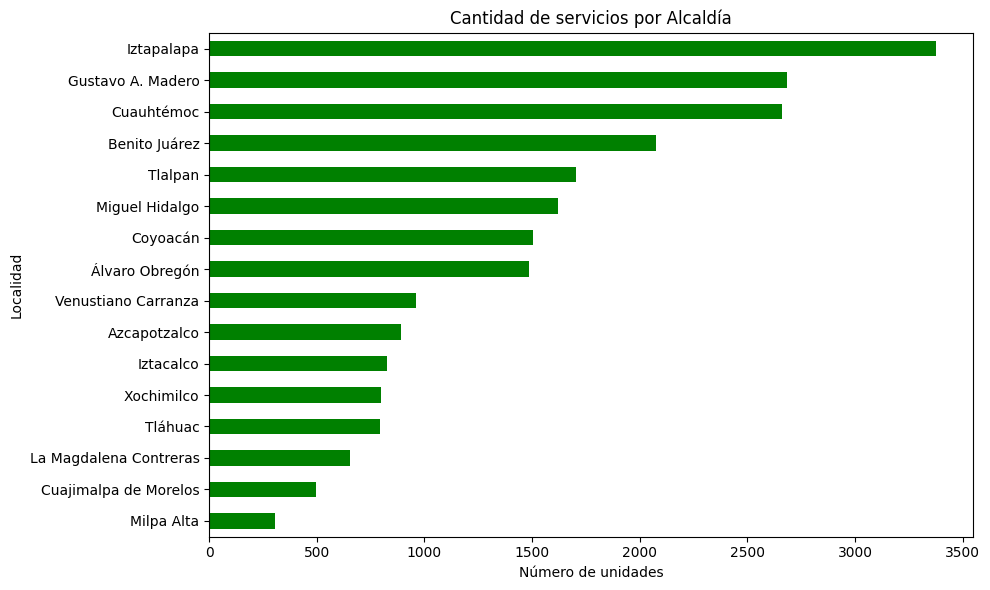

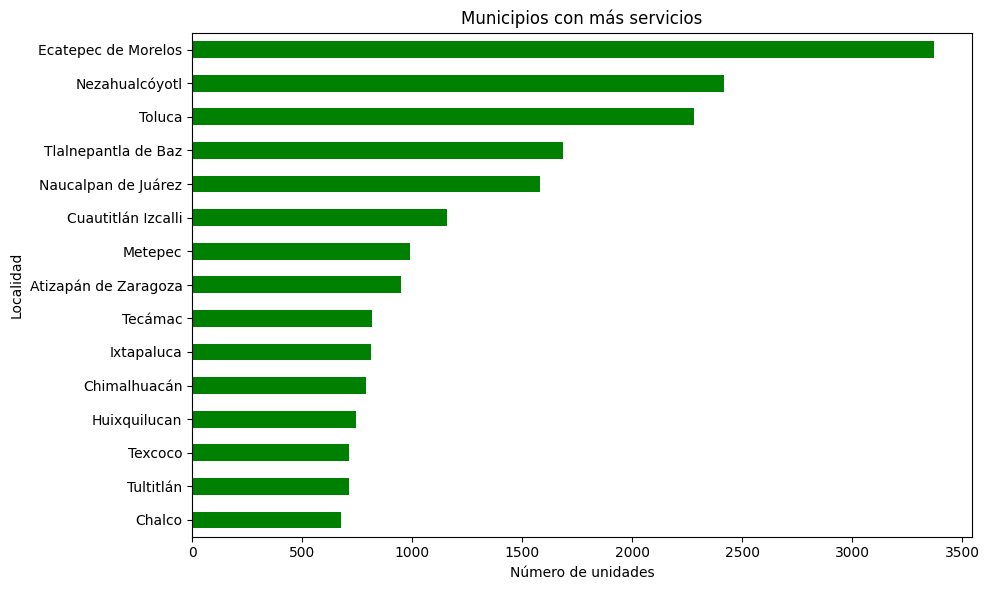

Text(0.5, 1.0, '15 Municipios con menos establecimientos')

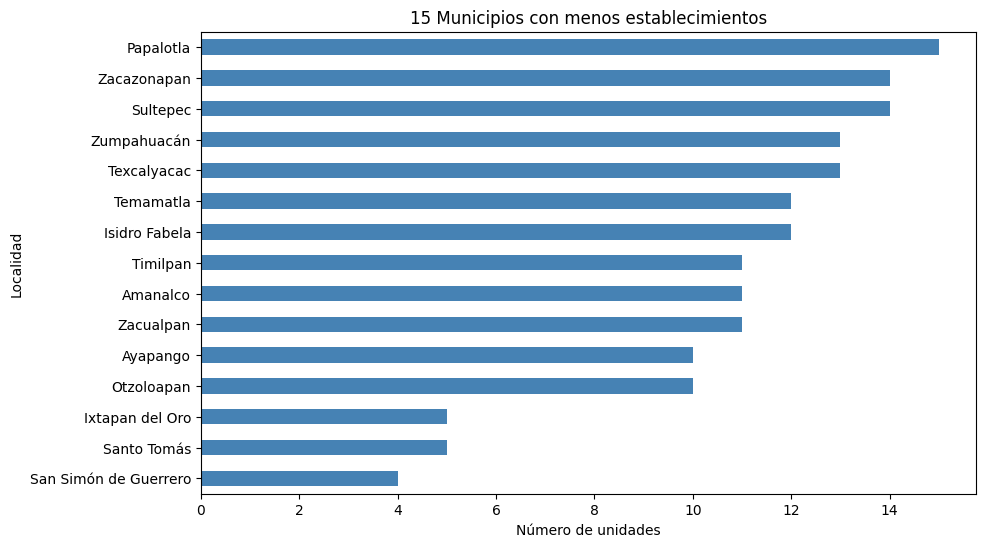

In [129]:
df_cdmx = df_metropolitana[df_metropolitana['entidad'] == 'Ciudad de México']
df_edomex = df_metropolitana[df_metropolitana['entidad'] == 'México']

# Municipios con más establecimientos.
df_cdmx['municipio'].value_counts().sort_values().plot(
    kind='barh', figsize=(10, 6), color='green', edgecolor='none')
plt.title('Cantidad de servicios por Alcaldía')
plt.xlabel('Número de unidades')
plt.ylabel('Localidad')
plt.tight_layout()
plt.show()

# Municipios con más establecimientos.
df_edomex['municipio'].value_counts().head(15).sort_values().plot(
    kind='barh', figsize=(10, 6), color='green', edgecolor='none')
plt.title('Municipios con más servicios')
plt.xlabel('Número de unidades')
plt.ylabel('Localidad')
plt.tight_layout()
plt.show()

df_edomex['municipio'].value_counts().tail(15).sort_values().plot(
    kind='barh', figsize=(10, 6), color='steelblue', edgecolor='none')
plt.ylabel('Localidad')
plt.xlabel('Número de unidades')
plt.title('15 Municipios con menos establecimientos')

**CDMX**
Las alcaldías como menos servicios médicos, son Táhuac, Magdalena Conteras y Milpa Alta. Mientras que en Izatapalapa, Gustavo A. Madero, y Cuáhtemoc son las que más tienen.

**EDOMEX**
Los municipios con más servicios con Ecatepec, Nexahualcóyotl y Toluca. Mientras, que los que tienen menos son: Ixtapan del Oro, Santo Tomás y San Simón de Guerrero.

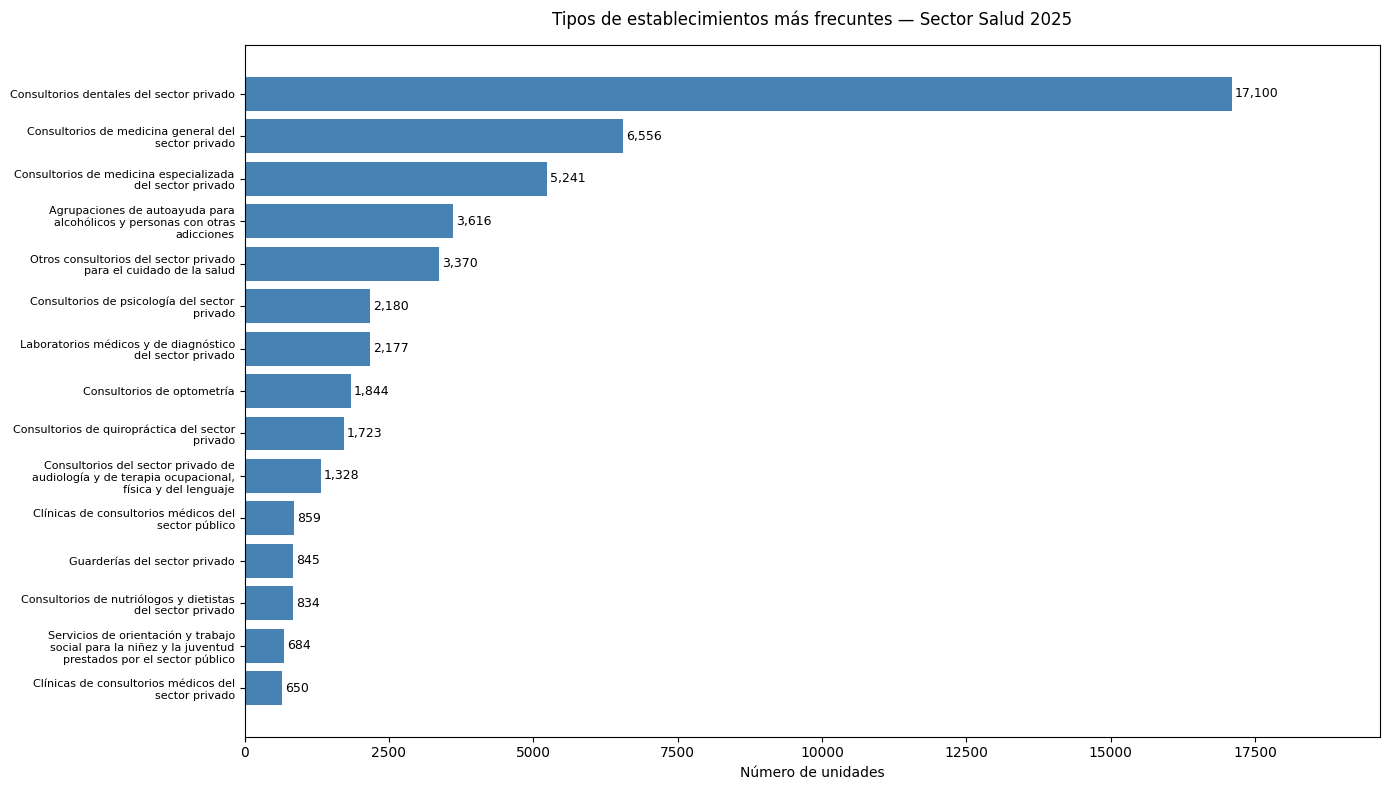

In [130]:
# Gráfica para tipos de establecimiento
fig, ax = plt.subplots(figsize=(14, 8))

top_act = (df_metropolitana.groupby(['codigo_act', 'nombre_act'])
           .size()
           .reset_index(name='n')
           .sort_values('n', ascending=True)
           .tail(15))

bars = ax.barh(range(len(top_act)), top_act['n'], color='steelblue', edgecolor='none')

# Etiquetas cortas — solo el valor al final de la barra
for bar, val in zip(bars, top_act['n']):
    ax.text(val + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

# Nombres en el eje Y con wrap automático
import textwrap
etiquetas = [textwrap.fill(nombre, width=40) for nombre in top_act['nombre_act']]
ax.set_yticks(range(len(top_act)))
ax.set_yticklabels(etiquetas, fontsize=8)

ax.set_title('Tipos de establecimientos más frecuntes — Sector Salud 2025', fontsize=12, pad=15)
ax.set_xlabel('Número de unidades')
ax.margins(x=0.15)  # espacio para los números al final

plt.tight_layout()
plt.show()

En este caso se puede observar que, en su mayoría, las entidades son privadas, a excepción de una clínica de consultorios médicos. Asimismo, se puede observar que los consultorios dentales privados son los que predominan alrededor de la zona metropolitana.


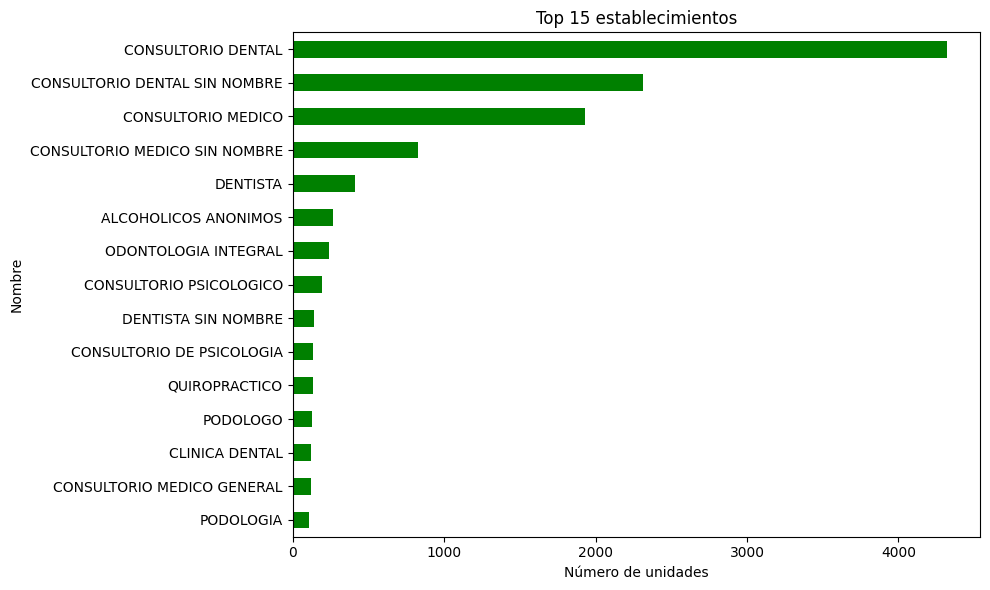

In [131]:
# Top 15 establecimientos plot
df_metropolitana['nom_estab'].value_counts().head(15).sort_values().plot(
    kind='barh', figsize=(10, 6), color='green', edgecolor='none')
plt.title('Top 15 establecimientos')
plt.xlabel('Número de unidades')
plt.ylabel('Nombre')
plt.tight_layout()
plt.show()

La mayoría de los establecimientos son dentales, de psicología, podología, quiroprácticos y establecimientos para alcohólicos anónimos. Dentro del top 15 de establecimientos médicos, hay consultorios médicos y generales. Es decir, abundan más los establecimientos enfocados al cuidado de la salud mental y lo dental.

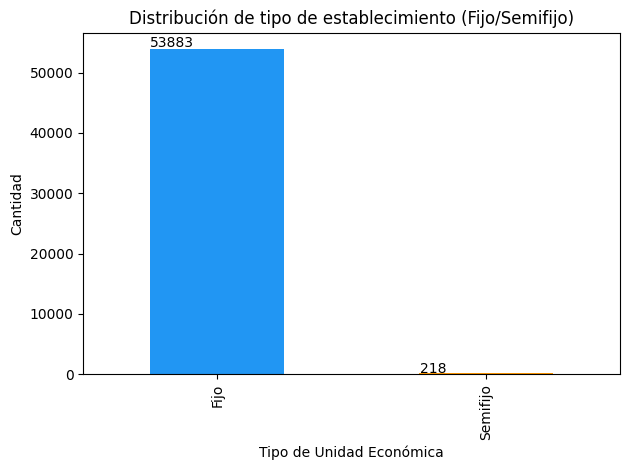

In [132]:
# Bar Plot tipoUniEco
ax = df_metropolitana['tipoUniEco'].value_counts().plot(kind='bar',
                                                     color=['#2196F3', '#FF9800'])
plt.title('Distribución de tipo de establecimiento (Fijo/Semifijo)')
plt.xlabel('Tipo de Unidad Económica')
plt.ylabel('Cantidad')
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.005, p.get_height() * 1.005))
plt.tight_layout()
plt.show()

La gráfica muestra cómo es que los establecimientos fijos son más predominantes que los semifijos, lo que sugiere que en su mayoría los consultorios, están de manera permanente, haciendo que haya una cantidad confiable de servicios médicos en la zona, sin riesgo a que estos dejen de existir o que su estancia sea temporal.

Antes de hacer la construcción de complejos simpliciales, es importante observar si existen duplicados.

In [133]:
df_analisis.duplicated().sum()

np.int64(5452)

In [134]:
# encontrar duplicados
df_metropolitana.duplicated().sum()

np.int64(0)

En este caso, es posible observar que cada una de las filas registradas en la base de datos es diferente. Sin embargo, existen casos en donde los establecimientos están en una misma ubicación. Dado que el siguiente paso es hacer complejos simpliciales de Čech/Vietoris-Rips para explorar la conectividad en función de distancias entre puntos, las distancias para estos establecimientos en particular serán cero. Por ende, se considera que, dado el número de datos que hay, se eliminarán los duplicados de la base de datos.

In [135]:
# Antes
print(df_metropolitana.shape)

# Quitar coordenadas duplicadas
df_metropolitana = df_metropolitana.drop_duplicates(subset=['latitud', 'longitud'])

# Después
print(f"Puntos eliminados: {54101 - len(df_metropolitana)}")

(54101, 42)
Puntos eliminados: 8199


In [136]:
df_cdmx = df_metropolitana[df_metropolitana['entidad'] == 'Ciudad de México']
df_edomex = df_metropolitana[df_metropolitana['entidad'] == 'México']

print(f"CDMX:   {len(df_cdmx)} puntos únicos")
print(f"EdoMex: {len(df_edomex)} puntos únicos")

CDMX:   17596 puntos únicos
EdoMex: 28306 puntos únicos


Debido a la magnitud de los datos, se opta por tomar un muestreo, en dónde de manera aleatoria se selecciona el 10% de establecimientos de cada municipio.

In [137]:
# Muestra estratificada por municipio/alcaldía
def muestra_proporcional(df, frac=0.30, min_n=4):
    return (df
        .groupby('municipio', group_keys=False)
        .apply(lambda x: x.sample(n=max(min_n, int(len(x) * frac)),
                                   random_state=42)))

df_cdmx_muestra   = muestra_proporcional(df_cdmx)
df_edomex_muestra = muestra_proporcional(df_edomex)
print(f"CDMX muestra:   {len(df_cdmx_muestra)}")
print(f"EdoMex muestra: {len(df_edomex_muestra)}")


/tmp/ipykernel_56269/3470063654.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=max(min_n, int(len(x) * frac)),


CDMX muestra:   5273
EdoMex muestra: 8456


/tmp/ipykernel_56269/3470063654.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=max(min_n, int(len(x) * frac)),


##  Construcción de Complejos Simpliciales

In [138]:
# Convertimos lat/lon a metros (UTM)
# para que las librerías puedan medir bien las distancias

transformer = Transformer.from_crs(
    "EPSG:4326",   # WGS84
    "EPSG:32614",  # UTM zona 14N (CDMX/EdoMex)
    always_xy=True
)

def convertir_a_utm(df):

    x, y = transformer.transform(
        df['longitud'].values,
        df['latitud'].values
    )

    points = np.column_stack((x, y))

    return points

In [139]:
# Combinar muestras
df_muestra = pd.concat([
    df_cdmx_muestra,
    df_edomex_muestra
])

# Transformador WGS84 -> UTM zona 14N
transformer = Transformer.from_crs(
    "EPSG:4326",
    "EPSG:32614",
    always_xy=True
)

# Convertir coordenadas
x, y = transformer.transform(
    df_muestra['longitud'].values,
    df_muestra['latitud'].values
)

# Matriz de puntos
points = np.column_stack((x, y))

print(points.shape)

points_cdmx = convertir_a_utm(df_cdmx_muestra) # convertir coordenadas CDMX

points_edomex= convertir_a_utm(df_edomex_muestra) # convertir coordenadas EDOMEX

print("CDMX:", points_cdmx.shape)
print("EdoMex:", points_edomex.shape)

(13729, 2)
CDMX: (5273, 2)
EdoMex: (8456, 2)


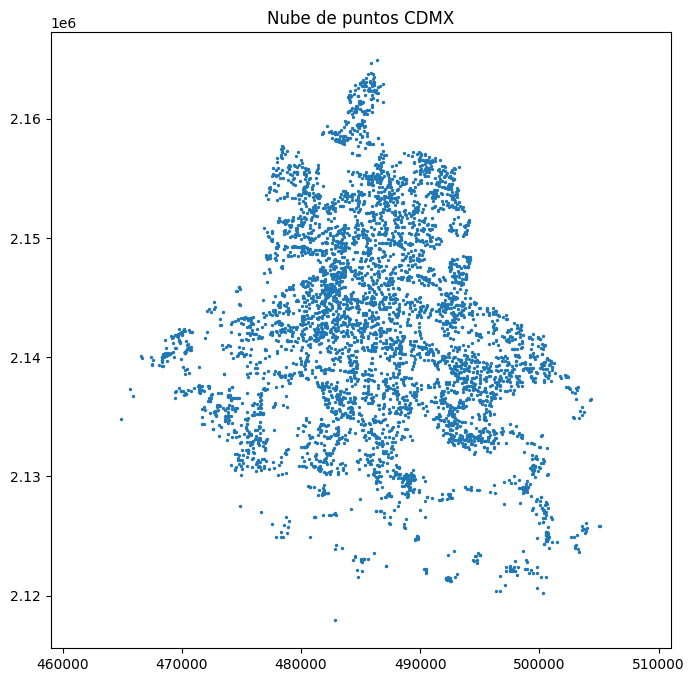

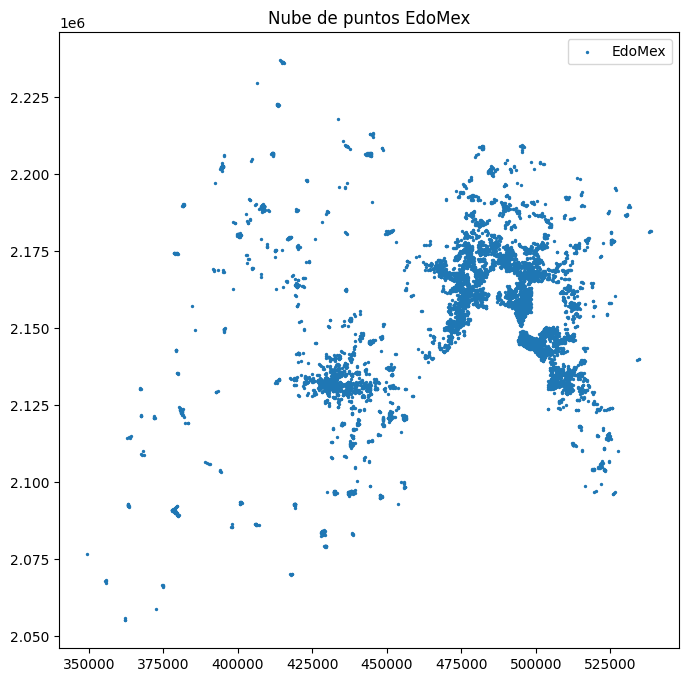

In [140]:
# Visaulizar los establecimientos en CDMX y EDOMEX

plt.figure(figsize=(8,8))

plt.scatter(
    points_cdmx[:,0],
    points_cdmx[:,1],
    s=2,
    label='CDMX'
)

plt.title("Nube de puntos CDMX")
plt.axis('equal')
plt.show()


plt.figure(figsize=(8,8))

plt.scatter(
    points_edomex[:,0],
    points_edomex[:,1],
    s=2,
    label='EdoMex'
)

plt.title("Nube de puntos EdoMex")
plt.legend()
plt.show()


De manera inicial se puede observar como es que al norte de la Ciudad de México hay más establecimientos que al sur. En el caso de EDOMEX, las localidades se concentran más en el oriente.

A continuación se construiran los complejos de Vitrois-Rips. Para ello, se probaran una lista de diversos parámetros para la distancia máxima que puede tener una arista. De esta manera será posible medir la conectividad que hay en las zonas dependiendo de la distancia que haya entre los establecimientos.


================ CDMX ================


Resumen CDMX


,radio,vertices,simplices
0,500,5273,93664
1,1000,5273,701428
2,1500,5273,2673187
3,2000,5273,7160051
4,3000,5273,29404620



================ EdoMex ================


Resumen EdoMex


,radio,vertices,simplices
0,500,8456,152122
1,1000,8456,951378
2,1500,8456,2914292
3,2000,8456,6771848
4,3000,8456,22839961


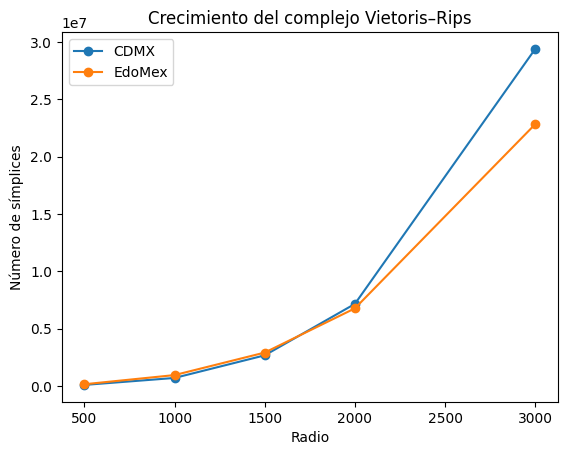

In [141]:

# ------------------------------------------------------------
# Radios a probar (en metros)
# ------------------------------------------------------------

radios = [500, 1000, 1500, 2000, 3000]

# ============================================================
# CDMX
# ============================================================

resultados_cdmx = []

print("\n================ CDMX ================\n")

for r in radios:

    # Construcción del complejo
    rips_cdmx = gd.RipsComplex(
        points=points_cdmx,
        max_edge_length=r
    )

    # max_dimension=2
    simplex_tree_cdmx = rips_cdmx.create_simplex_tree(
        max_dimension=2
    )

    # Información del complejo
    n_vertices = simplex_tree_cdmx.num_vertices()
    n_simplices = simplex_tree_cdmx.num_simplices()

    # Guardar resultados
    resultados_cdmx.append({
        "radio": r,
        "vertices": n_vertices,
        "simplices": n_simplices
    })

# Convertir a DataFrame
df_resultados_cdmx = pd.DataFrame(resultados_cdmx)

print("\nResumen CDMX")
display(df_resultados_cdmx)

# ============================================================
# EdoMex
# ============================================================

resultados_edomex = []

print("\n================ EdoMex ================\n")

for r in radios:
    # Construcción del complejo
    rips_edomex = gd.RipsComplex(
        points=points_edomex,
        max_edge_length=r
    )

    simplex_tree_edomex = rips_edomex.create_simplex_tree(
        max_dimension=2
    )

    # Información del complejo
    n_vertices = simplex_tree_edomex.num_vertices()
    n_simplices = simplex_tree_edomex.num_simplices()

    # Guardar resultados
    resultados_edomex.append({
        "radio": r,
        "vertices": n_vertices,
        "simplices": n_simplices
    })

# Convertir a DataFrame
df_resultados_edomex = pd.DataFrame(resultados_edomex)

print("\nResumen EdoMex")
display(df_resultados_edomex)


plt.plot(df_resultados_cdmx['radio'],
         df_resultados_cdmx['simplices'],
         marker='o',
         label='CDMX')

plt.plot(df_resultados_edomex['radio'],
         df_resultados_edomex['simplices'],
         marker='o',
         label='EdoMex')

plt.xlabel("Radio")
plt.ylabel("Número de símplices")
plt.title("Crecimiento del complejo Vietoris–Rips")
plt.legend()
plt.show()



En primer lugar se observa que el número de complejos simpliciales de CDMX es mayor al de EDOMEX, sugieriendo que hay mayor conectividad en la capital. Por otro lado, la gráfica muestra como es que el crecimiento de construcción de simplejos, para EDOMEX, es más lenta que el de la Ciudad de México.

En particular, se opta por tomar un radio de 2 km, ya que el el radio donde el complejo empieza a conectarse significativamente sin, hacerlo completamente.

Una vez decido esto, es posible contruir los complejos para un solo radio. Cabe destacar que en este caso, se tomará la dimensión máxima de 2, ya que se buscan explorar los huecos y cavidades. Al tener una mayor dimensión sería más complejo de visualizar.

In [142]:
print(df_resultados_cdmx[df_resultados_cdmx['radio'] == 2000])
print(df_resultados_edomex[df_resultados_edomex['radio'] == 2000])

   radio  vertices  simplices
3   2000      5273    7160051
   radio  vertices  simplices
3   2000      8456    6771848


In [143]:
# ------------------------------------------------------------
# CDMX
# ------------------------------------------------------------

result_cdmx = ripser(
    points_cdmx,
    maxdim=2,
    thresh=2000
)

diagrams_cdmx = result_cdmx['dgms']

# ------------------------------------------------------------
# EDOMEX
# ------------------------------------------------------------

result_edomex = ripser(
    points_edomex,
    maxdim=2,
    thresh=2000
)

diagrams_edomex = result_edomex['dgms']

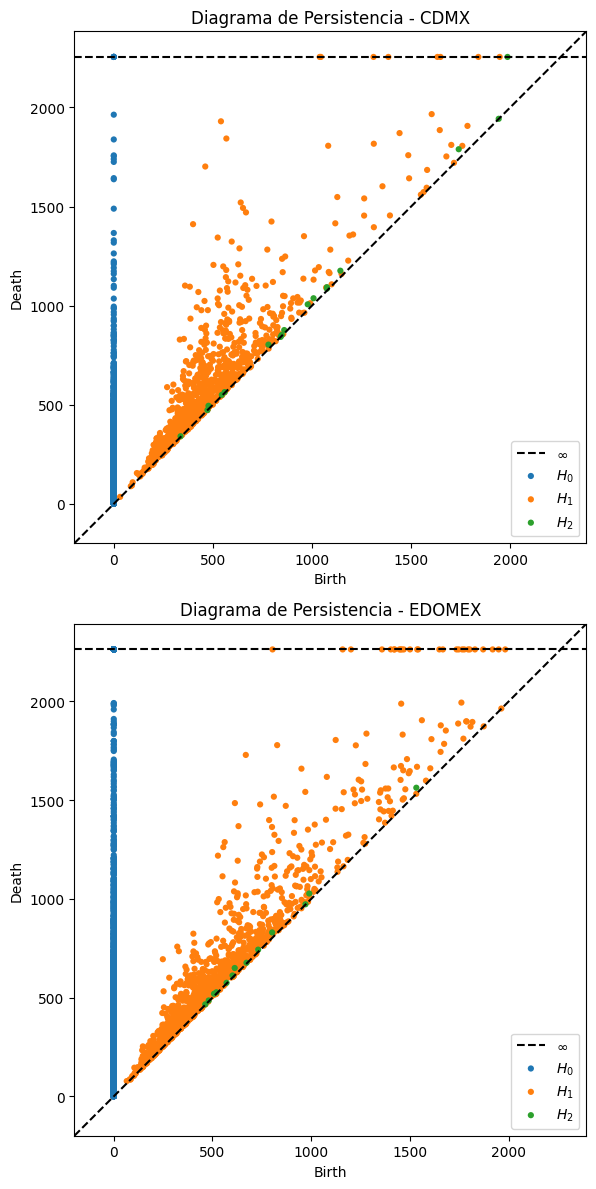

In [144]:

# ============================================================
#  DIAGRAMAS DE PERSISTENCIA
# ============================================================

plt.figure(figsize=(8, 12))

plt.subplot(2, 1, 1)
plot_diagrams(
    diagrams_cdmx,
    show=False
)
plt.title("Diagrama de Persistencia - CDMX")

plt.subplot(2, 1, 2)
plot_diagrams(
    diagrams_edomex,
    show=False
)
plt.title("Diagrama de Persistencia - EDOMEX")
plt.tight_layout()
plt.show()

**CDMX**
Para la Ciudad de México, se observa que dentro de los puntos que persisten más hay una componente conexa, 7 huecos de dimensión una y una cavidad. Igualmente, se observa que dentro del rango de 1500 y 2000 hay, algunas componentes conexas, huecos y cavidades. Sin embargo, estos mueren en un punto en específico.

Basado en esto, se infiere que hay 7 zonas en la Ciudad de México donde la cobertura a 2 km persenta huecos, sugiriendo acceso límitado. De igual manera, se encontró que existe una cavidad, significando, también una límitante en la distribución de servicios médicos en la capital.

**EDOMEX**
En cuanto al Estado de México se observa que hay una componente conexa y alrededror de 18 huecos de dimensión uno, que persisten. Por lo tanto, existen municipios en el estado, que cuentan con un nivel bajo de servicios médicos, lo que repercute en el acceso a la salud de las personas. Sin embargo, es importante mencionar, que en este caso, no hay ninguna cavidad que persiste.

Así como se observo en el análisis inicial, la capital tiene mayor conectividad que el Estado de México, lo que sugiere que los habitantes de esta CDMX tienen mayor acceso.

<Figure size 1000x500 with 0 Axes>

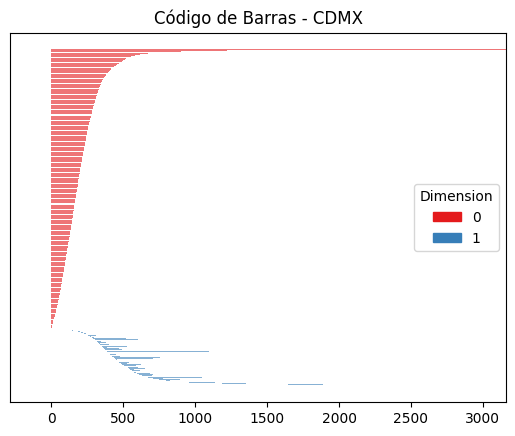

<Figure size 1000x500 with 0 Axes>

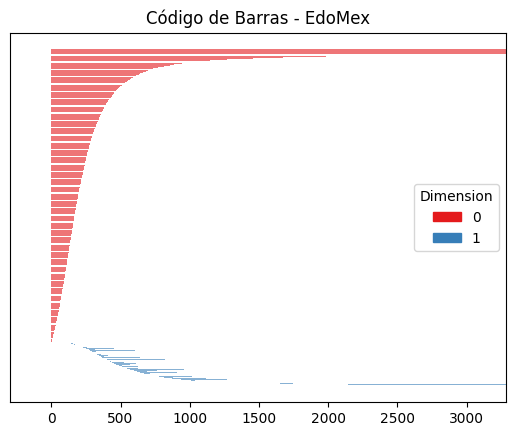

In [145]:
# Calcular persistencia con GUDHI
simplex_tree_cdmx.compute_persistence()
simplex_tree_edomex.compute_persistence()

# Barcodes
plt.figure(figsize=(10, 5))
gd.plot_persistence_barcode(simplex_tree_cdmx.persistence(), legend=True)
plt.title("Código de Barras - CDMX")
plt.show()

plt.figure(figsize=(10, 5))
gd.plot_persistence_barcode(simplex_tree_edomex.persistence(), legend=True)
plt.title("Código de Barras - EdoMex")
plt.show()

**CDMX**
Observando el código de barras, se confirma el hecho de que solo perstiste una sola componente conexa en la ciudad, lo que quiere decir los establecimientos de la ciudad forman una red conectada en un radio de 2km. De igual manera se observa, que persisten algunos huecos, lo que significa que existen areás de la ciudad, en dónde la población tiene que viajar a distancias más grandes, para poder tener acceso de salud.

Lo cual es consistente con lo encontrado anteriormente, dónde se observo que hay zonas, en la ciudad, como en el suroeste (Cuajimalpa de Morelos, Magdalena Contresas y Milpa Alta) , dónde hay menos servicios.

**EDOMEX**
En este caso, se observa que hay barras que tardan más en conectarse. Sin, embargo, de igual manera se observa que tienen más huecos. Esto podría indicar que existe una desigualdad, respecto a la distribución de servicios médicos, ya que mientras unos se encuentran conectados, hay otros lugar dónde no hay servicio.

Anteriormente, se había observado, que existe más puntos dentro de la zona oriente, por lo que se puede inferir que las zonas de menor acceso, son los municipios del poniente, cómo el municipio de Santo Tomás o San Simón de Guerrero.

Una vez teniendo una perspectiva general de lo que sucede en CDMX y EDOMEX, se hara un análisis similar, pero fijando los códigos 621 y 622, ya que estos contienen servicios médicos de consulta externa y servicios relacionados, y hospitales.

# Análisis solo para Hospitales y Consultoríos externos

In [146]:
df_metropolitana['codigo_act'].astype(str).str[:3].value_counts()

,count
codigo_act,
621,36965
624,7378
622,847
623,712


In [147]:
hospitales = df_metropolitana[df_metropolitana['codigo_act'].astype(str).str[:3] == '622']
consultorios = df_metropolitana[df_metropolitana['codigo_act'].astype(str).str[:3] == '621']


# Separar por entidad
hosp_cdmx = hospitales[hospitales['entidad'] == 'Ciudad de México']
hosp_edomex = hospitales[hospitales['entidad'] == 'México']

cons_cdmx = consultorios[consultorios['entidad'] == 'Ciudad de México']
cons_edomex = consultorios[consultorios['entidad'] == 'México']

print(f"Hospitales CDMX: {len(hosp_cdmx)}")
print(f"Consultorios CDMX: {len(cons_cdmx)}")
print(f"Hospitales EDOMEX: {len(hosp_edomex)}")
print(f"Consultorios EDOMEX: {len(cons_edomex)}")

Hospitales CDMX: 343
Consultorios CDMX: 13835
Hospitales EDOMEX: 504
Consultorios EDOMEX: 23130


Existen más consultorios médicos en la zona metropolitana que hospitales, por lo que surge la hipótesis de que los consultorios solventan la falta de hospitales en los huecos existentes.

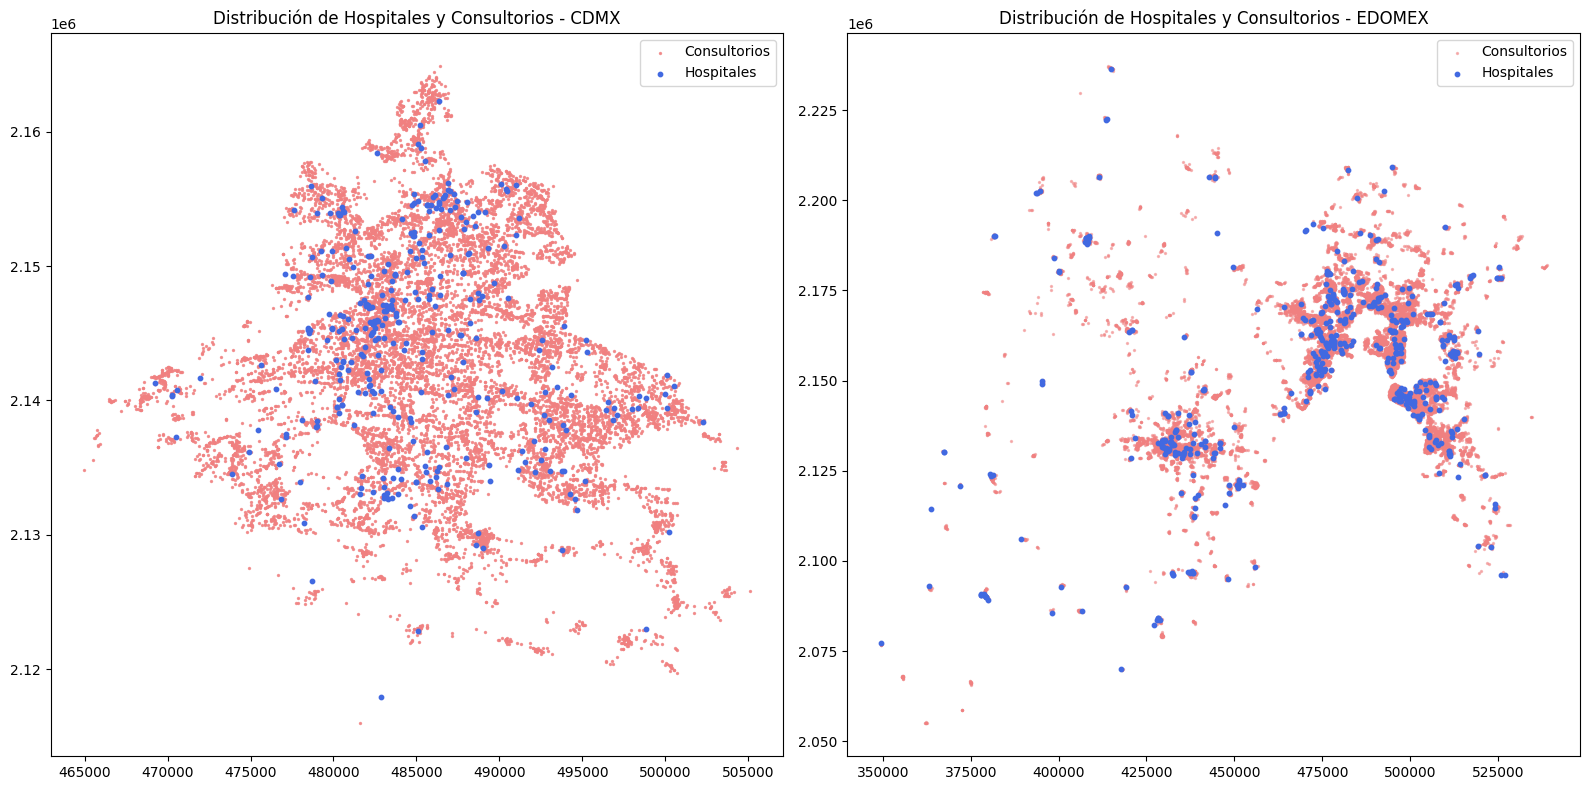

In [148]:
# Convertir a UTM
points_hosp_cdmx = convertir_a_utm(hosp_cdmx)
points_hosp_edomex = convertir_a_utm(hosp_edomex)

points_cons_cdmx = convertir_a_utm(cons_cdmx)
points_cons_edomex = convertir_a_utm(cons_edomex)

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].scatter(points_cons_cdmx[:,0], points_cons_cdmx[:,1], s=2, c='lightcoral', label='Consultorios', alpha=0.8)
axes[0].scatter(points_hosp_cdmx[:,0], points_hosp_cdmx[:,1], s=10, c='royalblue', label='Hospitales')
axes[0].set_title("Distribución de Hospitales y Consultorios - CDMX")
axes[0].legend()

axes[1].scatter(points_cons_edomex[:,0], points_cons_edomex[:,1], s=2, c='lightcoral', label='Consultorios', alpha=0.5)
axes[1].scatter(points_hosp_edomex[:,0], points_hosp_edomex[:,1], s=10, c='royalblue', label='Hospitales')
axes[1].set_title("Distribución de Hospitales y Consultorios - EDOMEX")
axes[1].legend()

plt.tight_layout()
plt.show()

Visualmente, se puede notar cómo es que existen más servicios médicos de consulta externa y servicios relacionado que hospitales. Sin embargo, persisten los espacios en blanco, que se encontraron en el análisis anterior. Por lo que, a pesar de que los consultorios, puedan llegar a satisfacer la demanda médica en ciertas zonas, aún así existen zonar que continuan teniendo una falta de servicios médicos.

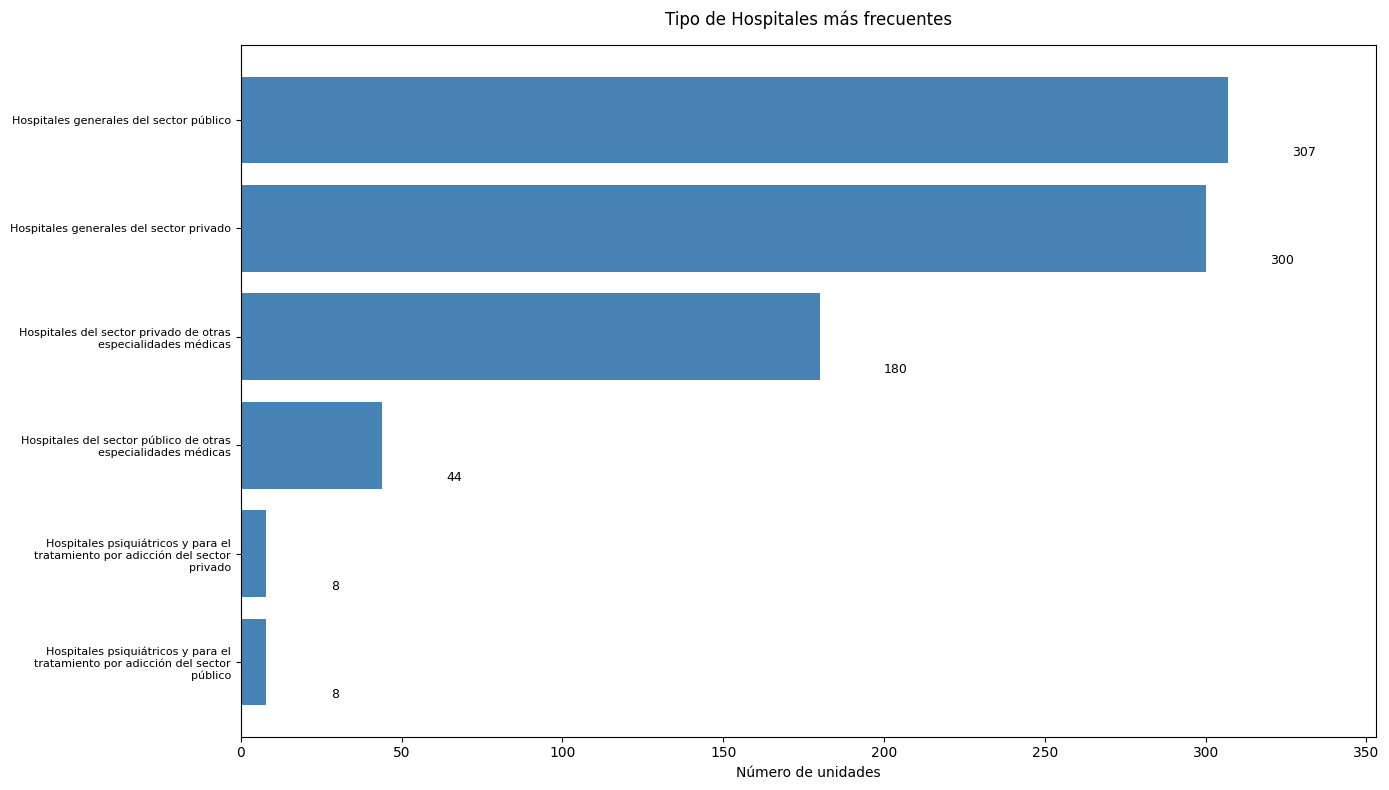

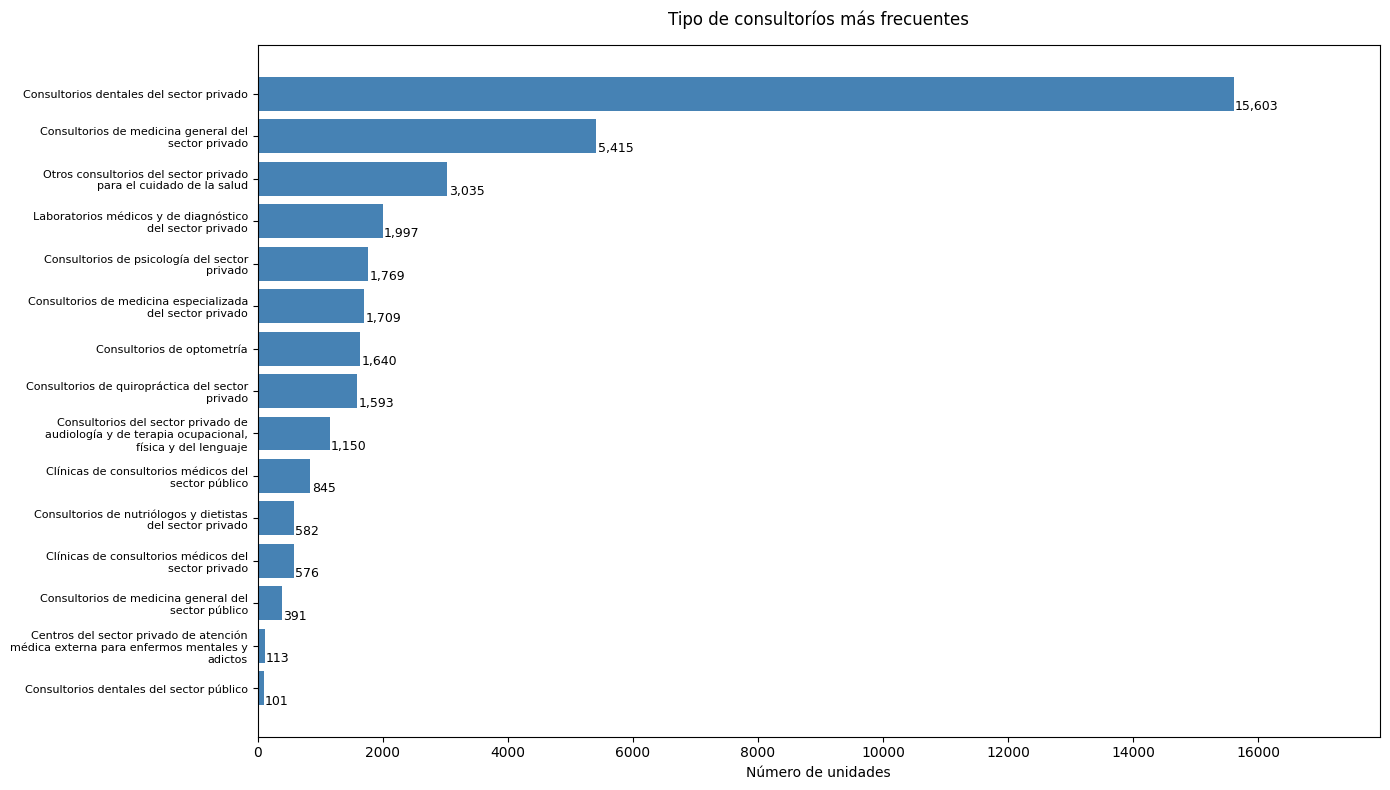

In [149]:
# Top 15 hospitales
# Gráfica para tipos de establecimiento
fig, ax = plt.subplots(figsize=(14, 8))

top_act = (hospitales.groupby(['codigo_act', 'nombre_act'])
           .size()
           .reset_index(name='n')
           .sort_values('n', ascending=True)
           .tail(15))

bars = ax.barh(range(len(top_act)), top_act['n'], color='steelblue', edgecolor='none')

# Etiquetas cortas — solo el valor al final de la barra
for bar, val in zip(bars, top_act['n']):
    ax.text(val + 20, bar.get_y() + bar.get_height()/8,
            f'{val:,}', va='center', fontsize=9)

# Nombres en el eje Y con wrap automático
import textwrap
etiquetas = [textwrap.fill(nombre, width=40) for nombre in top_act['nombre_act']]
ax.set_yticks(range(len(top_act)))
ax.set_yticklabels(etiquetas, fontsize=8)

ax.set_title('Tipo de Hospitales más frecuentes', fontsize=12, pad=15)
ax.set_xlabel('Número de unidades')
ax.margins(x=0.15)  # espacio para los números al final

plt.tight_layout()
plt.show()

# Top 15 consultoríos
# Gráfica para tipos de establecimiento
fig, ax = plt.subplots(figsize=(14, 8))

top_act = (consultorios.groupby(['codigo_act', 'nombre_act'])
           .size()
           .reset_index(name='n')
           .sort_values('n', ascending=True)
           .tail(15))

bars = ax.barh(range(len(top_act)), top_act['n'], color='steelblue', edgecolor='none')

# Etiquetas cortas — solo el valor al final de la barra
for bar, val in zip(bars, top_act['n']):
    ax.text(val + 20, bar.get_y() + bar.get_height()/8,
            f'{val:,}', va='center', fontsize=9)

# Nombres en el eje Y con wrap automático
import textwrap
etiquetas = [textwrap.fill(nombre, width=40) for nombre in top_act['nombre_act']]
ax.set_yticks(range(len(top_act)))
ax.set_yticklabels(etiquetas, fontsize=8)

ax.set_title('Tipo de consultoríos más frecuentes', fontsize=12, pad=15)
ax.set_xlabel('Número de unidades')
ax.margins(x=0.15)  # espacio para los números al final

plt.tight_layout()
plt.show()

En el caso de los hospitales, no es determinante si es del sector privado o público, ya que hay 3 tipos de establecimiento que son públicos y otros 3 privados. Sin embargo, en el caso de los consultoríos, es posibles observar que la mayoría de estos son privados.

Una vez teniendo esta información, es posible realizar complejos simpliciales que permitan analizar sí la hipótesis se satisface.

In [150]:
print(cons_edomex.groupby('municipio').size().min())
print(cons_edomex.groupby('municipio').size().sort_values().head(10))

1
municipio
Ixtapan del Oro          1
San Simón de Guerrero    3
Otzoloapan               4
Santo Tomás              4
Texcalyacac              6
Ecatzingo                6
Zacualpan                6
Temamatla                7
Ayapango                 8
Timilpan                 8
dtype: int64


In [159]:
# Hospitales y consultorios por alcaldía/municipio
hosp_por_municipio_cdmx = hosp_cdmx['municipio'].value_counts().rename('hospitales')
cons_por_municipio_cdmx = cons_cdmx['municipio'].value_counts().rename('consultorios')

hosp_por_municipio_edomex = hosp_edomex['municipio'].value_counts().rename('hospitales')
cons_por_municipio_edomex = cons_edomex['municipio'].value_counts().rename('consultorios')

# Combinar en un DataFrame — municipios sin hospitales
df_cdmx_dist = pd.concat([hosp_por_municipio_cdmx, cons_por_municipio_cdmx], axis=1).fillna(0).astype(int)
df_edomex_dist = pd.concat([hosp_por_municipio_edomex, cons_por_municipio_edomex], axis=1).fillna(0).astype(int)

# Ver municipios sin hospitales
print("CDMX sin hospitales:")
print(df_cdmx_dist[df_cdmx_dist['hospitales'] == 0])

print("\nEdoMex sin hospitales:")
print(df_edomex_dist[df_edomex_dist['hospitales'] == 0])

CDMX sin hospitales:
Empty DataFrame
Columns: [hospitales, consultorios]
Index: []

EdoMex sin hospitales:
                         hospitales  consultorios
municipio                                        
Xonacatlán                        0           132
Ocoyoacac                         0           121
Melchor Ocampo                    0            90
Ozumba                            0            56
Juchitepec                        0            50
Xalatlaco                         0            40
Tonatico                          0            34
Morelos                           0            30
Amatepec                          0            30
Nopaltepec                        0            25
San José del Rincón               0            25
Tenango del Aire                  0            20
Jilotzingo                        0            18
Villa de Allende                  0            17
Soyaniquilpan de Juárez           0            16
Joquicingo                        0        

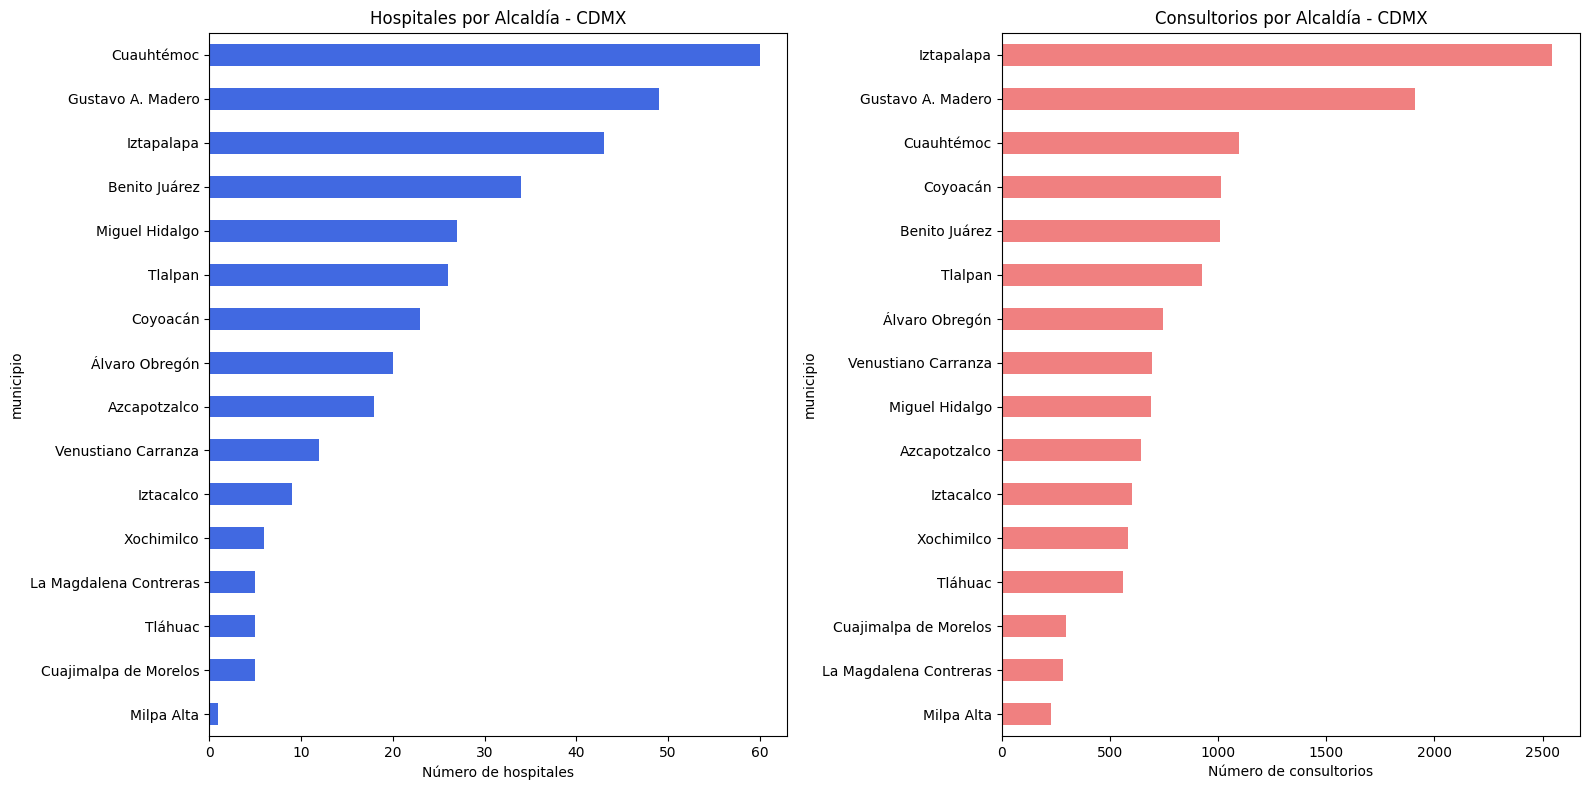

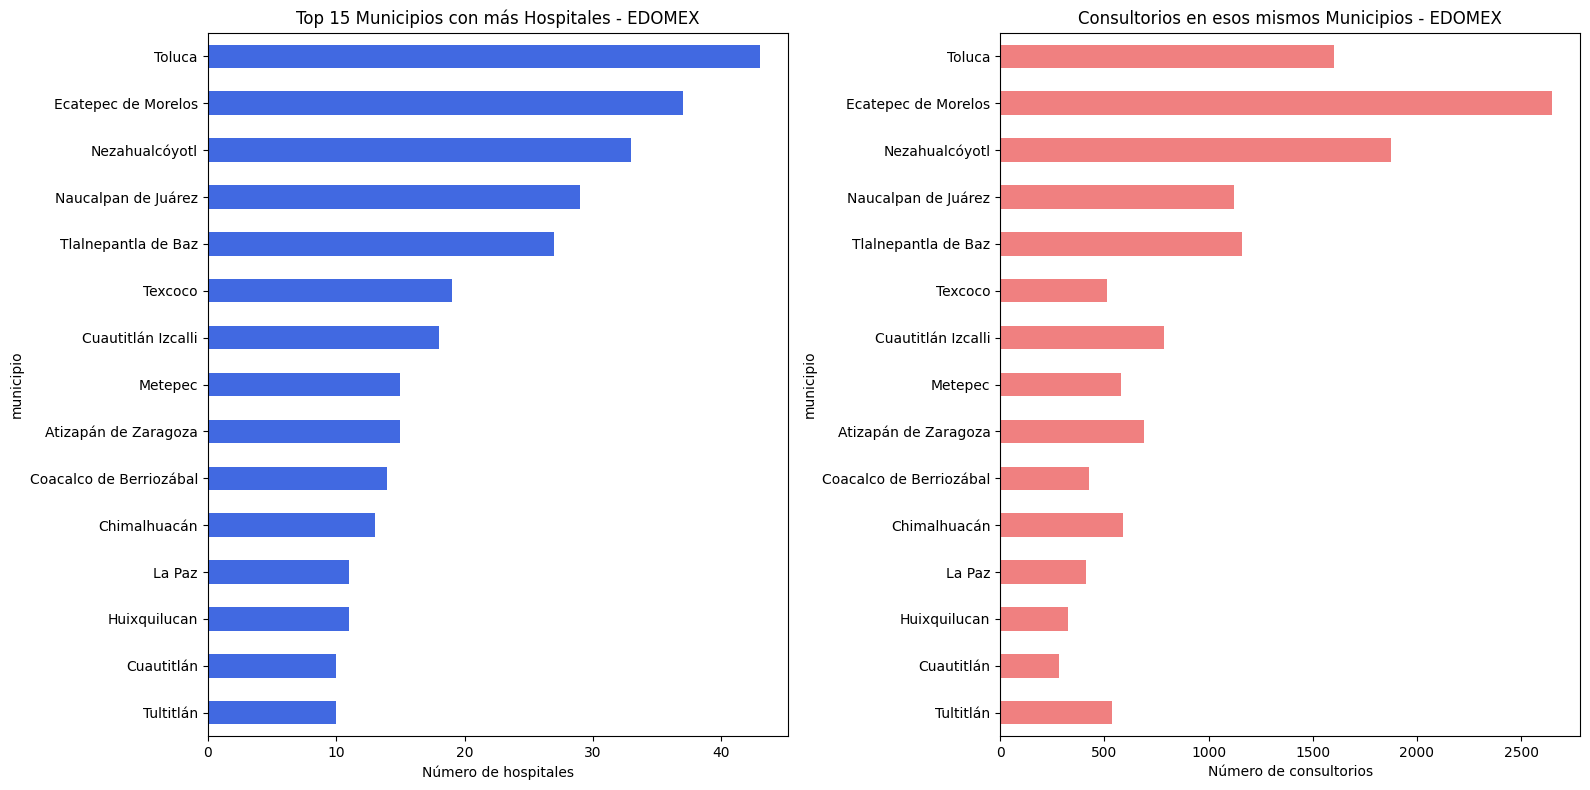

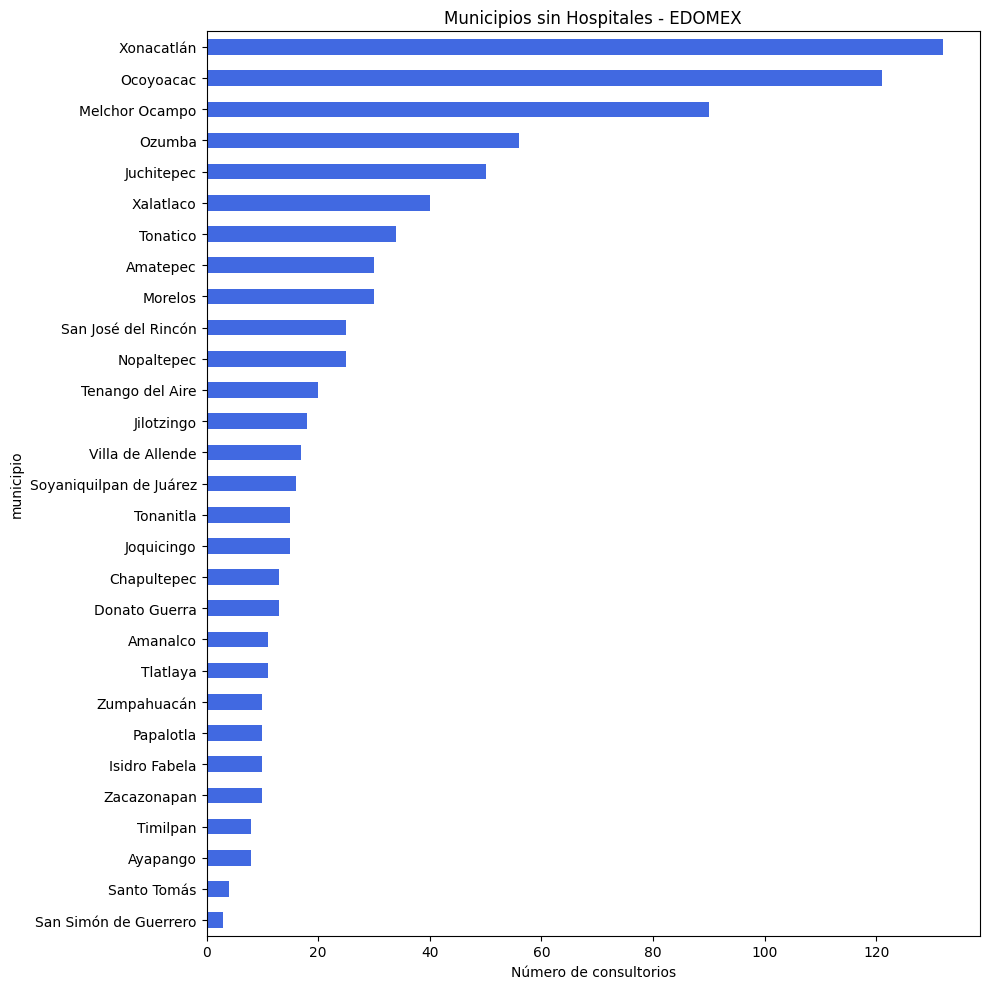

In [181]:
# ver numero hospitales y consultorios CDMX
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

df_cdmx_dist.sort_values('hospitales')['hospitales'].plot(
    kind='barh', ax=axes[0], color='royalblue')
axes[0].set_title('Hospitales por Alcaldía - CDMX')
axes[0].set_xlabel('Número de hospitales')

df_cdmx_dist.sort_values('consultorios')['consultorios'].plot(
    kind='barh', ax=axes[1], color='lightcoral')
axes[1].set_title('Consultorios por Alcaldía - CDMX')
axes[1].set_xlabel('Número de consultorios')

plt.tight_layout()
plt.show()

# ver numero hospitales y consultorios EDOMEX
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

df_edomex_dist.sort_values('hospitales').tail(15)['hospitales'].plot(
    kind='barh', ax=axes[0], color='royalblue')
axes[0].set_title('Top 15 Municipios con más Hospitales - EDOMEX')
axes[0].set_xlabel('Número de hospitales')

df_edomex_dist.sort_values('hospitales').tail(15)['consultorios'].plot(
    kind='barh', ax=axes[1], color='lightcoral')
axes[1].set_title('Consultorios en esos mismos Municipios - EDOMEX')
axes[1].set_xlabel('Número de consultorios')

plt.tight_layout()
plt.show()

# Municipios sin hospitales
sin_hosp_edomex = df_edomex_dist[df_edomex_dist['hospitales'] == 0].sort_values('consultorios')

sin_hosp_edomex['consultorios'].plot(
    kind='barh', figsize=(10, 10), color='royalblue')
plt.title('Municipios sin Hospitales - EDOMEX')
plt.xlabel('Número de consultorios')
plt.tight_layout()
plt.show()

**CDMX**
Es posible observar como es que en la Ciudad de México, todas las alcaldías cuentan con hospitales y consultorios, aunque en algunos hay una mayor cantidad, cómo es el caso de Gustavo A. Madero, Iztapalapa y Cuauhtémoc.

**EDOMEX**
En este caso tomando los top 15 municipios con hospitales en el estado, se oberva que Ecatepec es el que más consultorios tiene. Asismismo, en este caso, se observa que existen municipios sin hospitales, como Xonacatlán, que se encuentra al norte del estado.

Una vez hecho el análisis, lo siguiente es crear complejos de Čech/Vietoris-Rips.

En este caso, unicámente se hace un muestreo por lo consultoríos ya que la cantidad de datos para hospitales es menor a 1000, siendo esto aceptable para que la librería ripser lo pueda soportar.

In [155]:
# Tomas muestras de consultorios
cons_cdmx_muestra = muestra_proporcional(cons_cdmx, min_n = 1)
cons_edomex_muestra = muestra_proporcional(cons_edomex, min_n = 1)

# Convertirlo en puntos
points_cons_cdmx_m = convertir_a_utm(cons_cdmx_muestra)
points_cons_edomex_m = convertir_a_utm(cons_edomex_muestra)

# Combinar con hospitales (sin muestreo)
points_combinado_cdmx = np.vstack([points_hosp_cdmx, points_cons_cdmx_m])
points_combinado_edomex = np.vstack([points_hosp_edomex, points_cons_edomex_m])

print(f"Combinado CDMX:   {len(points_combinado_cdmx)}")
print(f"Combinado EDOMEX: {len(points_combinado_edomex)}")

/tmp/ipykernel_56269/3470063654.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=max(min_n, int(len(x) * frac)),


Combinado CDMX:   4487
Combinado EdoMex: 7397


/tmp/ipykernel_56269/3470063654.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=max(min_n, int(len(x) * frac)),


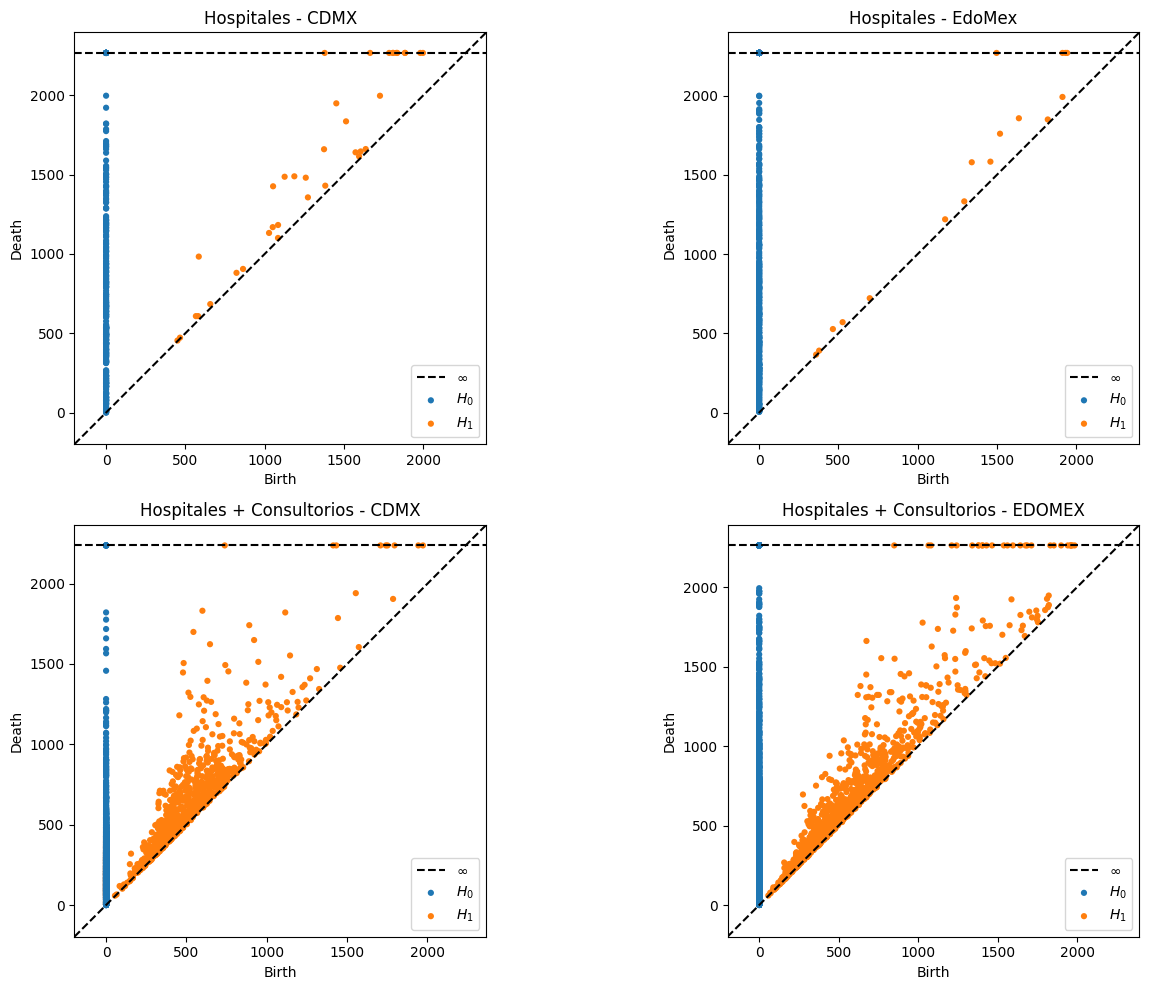

In [157]:
# al igual que antes se usa 2000
result_hosp_cdmx = ripser(points_hosp_cdmx, maxdim=1, thresh=2000)
result_hosp_edomex = ripser(points_hosp_edomex, maxdim=1, thresh=2000)
result_combinado_cdmx = ripser(points_combinado_cdmx, maxdim=1, thresh=2000)
result_combinado_edomex = ripser(points_combinado_edomex, maxdim=1, thresh=2000)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# hospitales solos
axes[0,0].set_title("Hospitales - CDMX")
plt.sca(axes[0,0])
plot_diagrams(result_hosp_cdmx['dgms'], show=False)

axes[0,1].set_title("Hospitales - EDOMEX")
plt.sca(axes[0,1])
plot_diagrams(result_hosp_edomex['dgms'], show=False)

# combinado
axes[1,0].set_title("Hospitales + Consultorios - CDMX")
plt.sca(axes[1,0])
plot_diagrams(result_combinado_cdmx['dgms'], show=False)

axes[1,1].set_title("Hospitales + Consultorios - EDOMEX")
plt.sca(axes[1,1])
plot_diagrams(result_combinado_edomex['dgms'], show=False)

plt.tight_layout()
plt.show()

**CDMX**
En este caso, se observa que aún teniendo consultoríos, los huecos persistentes se mantienen. Es decir que la incorporación de consultoríos alrededor de la ciudad, no solventa la ausencia de hospitales en ciertas areás.

**EDOMEX**
En el caso del estado, se observa que hay un aumento en el número de huecos. Sin embargo, esto se puede deber a que existen municipios con falta de hospitales, mientras que si tienen consultorios. Es decir que el aumento de huecos, se debe a que el gráfico de persistensia de hospitales, no contabiliza a los municipios sin hospitales. Por ende, al añadir los consultoríos, se evidencia la desigualdad que existe en el estado, ya que hay zonas en donde los habitantes unicámente pueden ser atendidos mediante consultorios.

Por lo tanto, en el caso de la Ciudad de México, se observa que el número de huecos, no cambia al añadír consultorios. Empero, este no es el caso, para EDOMEX, ya que en este caso, hay zonas en dónde unicámente se tienen consultorios.

<Figure size 1000x500 with 0 Axes>

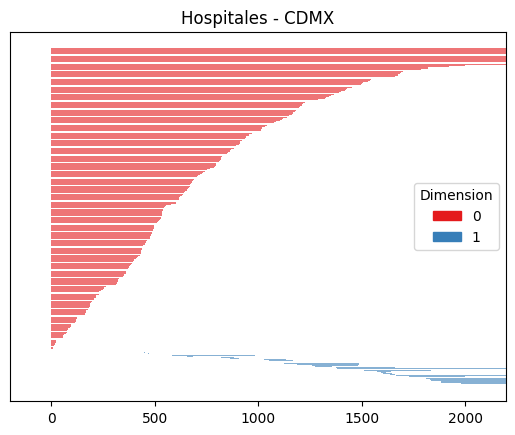

<Figure size 1000x500 with 0 Axes>

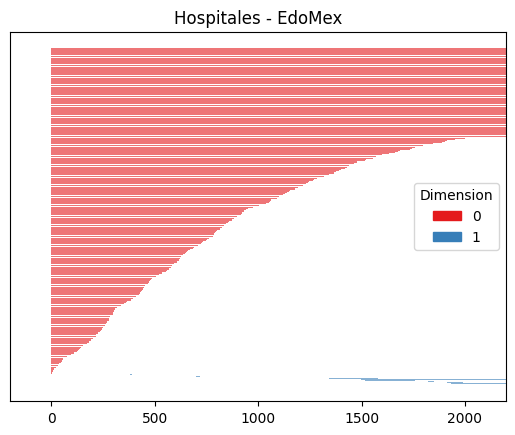

<Figure size 1000x500 with 0 Axes>

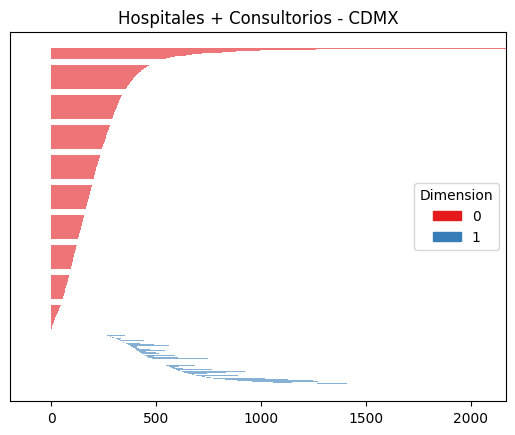

<Figure size 1000x500 with 0 Axes>

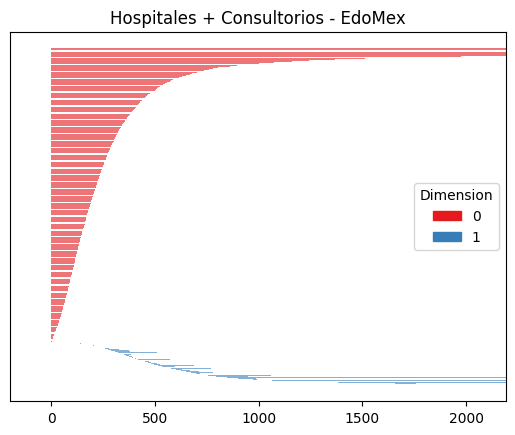

In [158]:

# Barcodes
simplex_hosp_cdmx = gd.RipsComplex(points=points_hosp_cdmx, max_edge_length=2000).create_simplex_tree(max_dimension=2)
simplex_hosp_edomex = gd.RipsComplex(points=points_hosp_edomex, max_edge_length=2000).create_simplex_tree(max_dimension=2)
simplex_comb_cdmx = gd.RipsComplex(points=points_combinado_cdmx, max_edge_length=2000).create_simplex_tree(max_dimension=2)
simplex_comb_edomex = gd.RipsComplex(points=points_combinado_edomex, max_edge_length=2000).create_simplex_tree(max_dimension=2)

for st, titulo in [
    (simplex_hosp_cdmx, "Hospitales - CDMX"),
    (simplex_hosp_edomex, "Hospitales - EDOMEX"),
    (simplex_comb_cdmx, "Hospitales + Consultorios - CDMX"),
    (simplex_comb_edomex, "Hospitales + Consultorios - EDOMEX")
]:
    st.compute_persistence()
    plt.figure(figsize=(10, 5))
    gd.plot_persistence_barcode(st.persistence(), legend=True)
    plt.title(titulo)
    plt.show()

**CDMX**
En este caso, se puede observar que existen huecos que persisten menos al agregar los consultoríos. Esto sugiere que los consultorios de una manera logran complementar a los servicios hospitalarios, pero siguen existiendo zonas con falta de acceso.

**EDOMEX**
En el caso de EDOMEX, se observa, cómo es que existe un aumento en el número de huecos. Por ende, esto evidencia la existencia de una desigualdad al acceso de hospitales en la el estado.